In [1]:
!pip install tensorflow scikit-learn pandas matplotlib seaborn nltk -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print(f"TensorFlow: {tf.__version__}")
print("All libraries loaded successfully")

TensorFlow: 2.20.0
All libraries loaded successfully


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("customer_support_text_classification.csv")
print("Dataset loaded successfully")

Saving customer_support_text_classification.csv to customer_support_text_classification (1).csv
Dataset loaded successfully


In [3]:
# ============================================================
# Task 1: Dataset Understanding
# ============================================================

print(f"=== Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print(f"\n=== Columns ===")
print(df.dtypes)

print(f"\n=== First 5 Rows ===")
print(df.head())

print(f"\n=== Target Class Distribution ===")
print(df['sentiment_label'].value_counts())

print(f"\n=== Channel Distribution ===")
print(df['channel'].value_counts())

print(f"\n=== Text Length Stats ===")
df['text_length'] = df['customer_message'].str.split().str.len()
print(df['text_length'].describe().round(2))

print(f"\n=== Sample Text Records ===")
for _, row in df.sample(3, random_state=42).iterrows():
    print(f"  [{row['sentiment_label'].upper()}] {row['customer_message'][:80]}...")

=== Shape ===
Rows: 1500, Columns: 6

=== Columns ===
ticket_id           object
channel             object
customer_message    object
sentiment_label     object
word_count           int64
urgent_flag          int64
dtype: object

=== First 5 Rows ===
  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  

=== Target Class Distribution ==

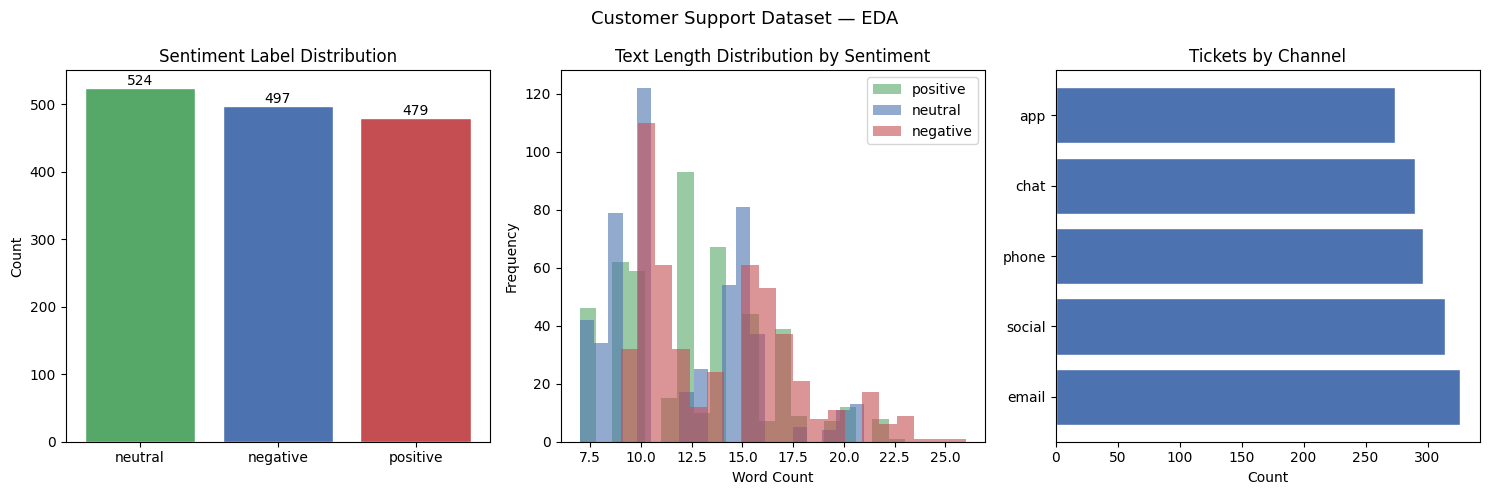

EDA plots saved


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Class distribution
counts = df['sentiment_label'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['#55A868', '#4C72B0', '#C44E52'],
            edgecolor='white')
axes[0].set_title("Sentiment Label Distribution")
axes[0].set_ylabel("Count")
for i, (label, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val + 5, str(val), ha='center', fontsize=10)

# Text length distribution by sentiment
for label, color in zip(['positive', 'neutral', 'negative'],
                        ['#55A868', '#4C72B0', '#C44E52']):
    subset = df[df['sentiment_label'] == label]['text_length']
    axes[1].hist(subset, bins=20, alpha=0.6, label=label, color=color)
axes[1].set_title("Text Length Distribution by Sentiment")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# Channel distribution
ch_counts = df['channel'].value_counts()
axes[2].barh(ch_counts.index, ch_counts.values, color='#4C72B0',
             edgecolor='white')
axes[2].set_title("Tickets by Channel")
axes[2].set_xlabel("Count")

plt.suptitle("Customer Support Dataset — EDA", fontsize=13)
plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150)
plt.show()
print("EDA plots saved")



## Task 1 — Dataset Observations

The dataset contains 1500 customer support tickets across 5
channels: email, social, phone, chat, and app.

The target variable is `sentiment_label` with three classes:
- **Neutral:** 524 tickets (34.9%)
- **Negative:** 497 tickets (33.1%)
- **Positive:** 479 tickets (31.9%)

The class distribution is well-balanced — no class dominates,
which means the model can learn all three sentiment classes
without bias correction.

Average text length is approximately 12-15 words per ticket.
Negative tickets tend to be slightly longer, suggesting
customers write more when expressing complaints — consistent
with real-world customer support behaviour.

In [5]:
# ============================================================
# Task 2: Text Preprocessing
# ============================================================

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove special characters, numbers, punctuation
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = text.split()
    # Remove stopwords
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['customer_message'].apply(clean_text)

print("Text preprocessing complete.")
print(f"\nSample — Before vs After cleaning:")
for i in range(3):
    print(f"\n  Original : {df['customer_message'].iloc[i]}")
    print(f"  Cleaned  : {df['clean_text'].iloc[i]}")

print(f"\nAverage tokens before cleaning: {df['word_count'].mean():.1f}")
print(f"Average tokens after cleaning : {df['clean_text'].str.split().str.len().mean():.1f}")

Text preprocessing complete.

Sample — Before vs After cleaning:

  Original : I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
  Cleaned  : need information payment process ticket number please respond soon possible

  Original : I need information about the payment process.
  Cleaned  : need information payment process

  Original : The refund process was fast and convenient. I appreciate the quick response.
  Cleaned  : refund process fast convenient appreciate quick response

Average tokens before cleaning: 12.7
Average tokens after cleaning : 6.6


In [6]:
# Encode labels
label_map     = {'positive': 0, 'neutral': 1, 'negative': 2}
label_inverse = {v: k for k, v in label_map.items()}
df['label']   = df['sentiment_label'].map(label_map)

X = df['clean_text'].values
y = df['label'].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"\nLabel mapping: {label_map}")

Training samples : 1200
Test samples     : 300

Label mapping: {'positive': 0, 'neutral': 1, 'negative': 2}


In [7]:
# ============================================================
# Task 3: Text Vectorization — TF-IDF
# ============================================================

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test) : {X_test_tfidf.shape}")
print(f"\nTop 20 TF-IDF features:")
print(tfidf.get_feature_names_out()[:20])

TF-IDF matrix shape (train): (1200, 428)
TF-IDF matrix shape (test) : (300, 428)

Top 20 TF-IDF features:
['account' 'account details' 'account keeps' 'account request'
 'account worked' 'account working' 'activate' 'activate analytics'
 'activate login' 'activate notifications' 'activate payment'
 'activate profile' 'activate report' 'activate tracking' 'activate video'
 'ago' 'ago please' 'ago ticket' 'analytics' 'analytics easy']



## Task 3 — Why Text Must Be Converted to Vectors

Machine learning models operate exclusively on numbers —
they cannot process raw strings directly. Converting text
to numerical vectors is therefore a mandatory preprocessing
step for any NLP model.

**TF-IDF (Term Frequency-Inverse Document Frequency)**
assigns each word a weight based on two factors: how often
it appears in a specific document (TF) and how rare it is
across all documents (IDF). Common words like "the" or
"please" get low weights because they appear everywhere and
carry no sentiment signal. Domain-specific words like
"frustrated", "resolved", or "excellent" get high weights
because they are more informative.

**Bigrams (ngram_range=(1,2)):** We include two-word
combinations alongside single words. "Not happy" as a
bigram captures the negation that a unigram model would
miss — "not" and "happy" individually suggest opposite
sentiments, but together they clearly signal negativity.

The resulting sparse matrix has one column per vocabulary
term and one row per ticket — each ticket is now a
numerical vector the model can learn from.

=== Logistic Regression + TF-IDF ===
Test Accuracy: 100.00%

              precision    recall  f1-score   support

    Positive       1.00      1.00      1.00        96
     Neutral       1.00      1.00      1.00       105
    Negative       1.00      1.00      1.00        99

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



<Figure size 700x500 with 0 Axes>

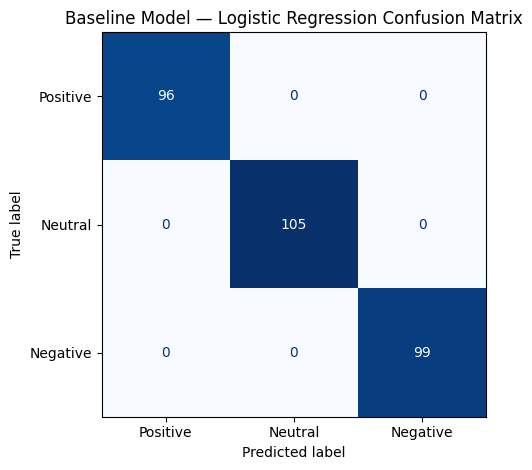

In [8]:
# ============================================================
# Task 4: Baseline Model — Logistic Regression with TF-IDF
# ============================================================

lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)
acc_lr    = accuracy_score(y_test, y_pred_lr)

print(f"=== Logistic Regression + TF-IDF ===")
print(f"Test Accuracy: {acc_lr*100:.2f}%\n")
print(classification_report(
    y_test, y_pred_lr,
    target_names=['Positive', 'Neutral', 'Negative']
))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(7, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Positive', 'Neutral', 'Negative']
)
disp.plot(colorbar=False, cmap='Blues')
plt.title("Baseline Model — Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.savefig("baseline_confusion_matrix.png", dpi=150)
plt.show()

In [9]:
# ============================================================
# Task 5: Sequence Model — LSTM
# ============================================================

# Tokenize text for LSTM
VOCAB_SIZE  = 5000
MAX_LEN     = 50
EMBED_DIM   = 64

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad sequences to fixed length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN,
                             padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN,
                             padding='post', truncating='post')

print(f"Vocabulary size     : {VOCAB_SIZE}")
print(f"Max sequence length : {MAX_LEN}")
print(f"X_train_pad shape   : {X_train_pad.shape}")
print(f"X_test_pad shape    : {X_test_pad.shape}")
print(f"\nSample padded sequence:")
print(X_train_pad[0])

Vocabulary size     : 5000
Max sequence length : 50
X_train_pad shape   : (1200, 50)
X_test_pad shape    : (300, 50)

Sample padded sequence:
[11  9 59 60 61  2  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0]


In [10]:
# Build LSTM model
lstm_model = keras.Sequential([
    layers.Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(3, activation='softmax')
])

lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

# Train
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - accuracy: 0.3392 - loss: 1.0991 - val_accuracy: 0.3222 - val_loss: 1.1047
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.3255 - loss: 1.1007 - val_accuracy: 0.3222 - val_loss: 1.0991
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.3559 - loss: 1.0989 - val_accuracy: 0.3222 - val_loss: 1.0992
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.3490 - loss: 1.0991 - val_accuracy: 0.3222 - val_loss: 1.1002
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.3529 - loss: 1.0991 - val_accuracy: 0.3222 - val_loss: 1.1007
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.3529 - loss: 1.0983 - val_accuracy: 0.3222 - val_loss: 1.1001
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.3529 - loss: 1.0990 - val_accuracy: 0.3222 - val_loss: 1.0995
Epoch 8/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.3559 - loss: 1.0982 - val_accuracy: 0.3222 

In [11]:
# Evaluate LSTM
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test, verbose=0)
y_pred_lstm = np.argmax(lstm_model.predict(X_test_pad), axis=1)

print(f"=== LSTM Model ===")
print(f"Test Accuracy: {lstm_acc*100:.2f}%\n")
print(classification_report(
    y_test, y_pred_lstm,
    target_names=['Positive', 'Neutral', 'Negative']
))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
=== LSTM Model ===
Test Accuracy: 35.00%

              precision    recall  f1-score   support

    Positive       0.00      0.00      0.00        96
     Neutral       0.35      1.00      0.52       105
    Negative       0.00      0.00      0.00        99

    accuracy                           0.35       300
   macro avg       0.12      0.33      0.17       300
weighted avg       0.12      0.35      0.18       300



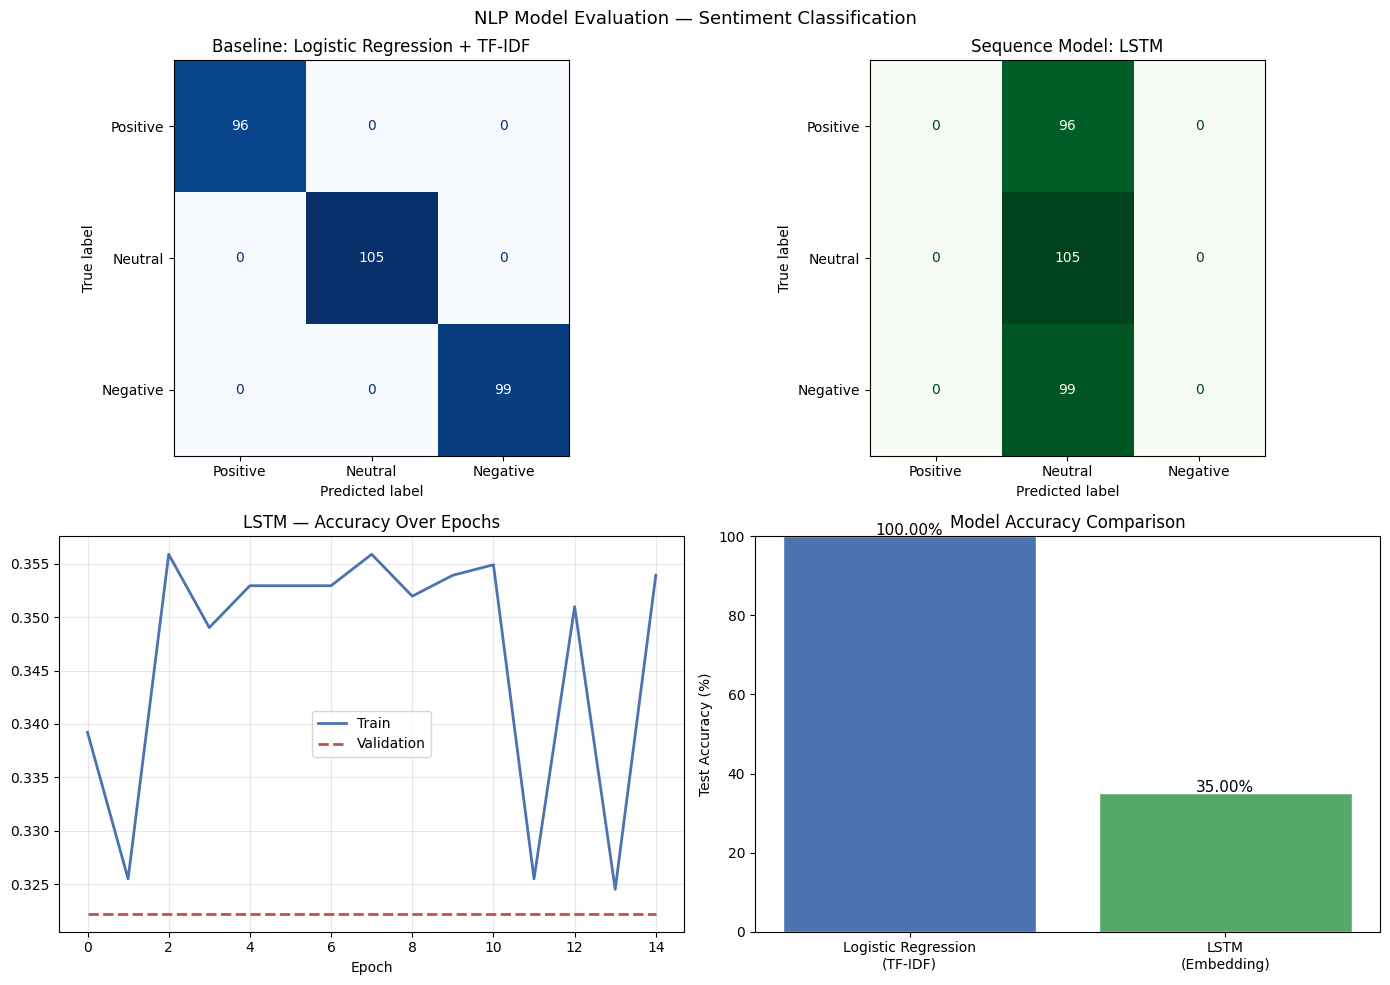

model_evaluation.png saved
sample_predictions.txt saved


In [12]:
# ============================================================
# Save required result files
# ============================================================

# 1 — model_evaluation.png
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Baseline confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr,
    display_labels=['Positive','Neutral','Negative']).plot(
    ax=axes[0][0], colorbar=False, cmap='Blues')
axes[0][0].set_title("Baseline: Logistic Regression + TF-IDF")

# LSTM confusion matrix
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
ConfusionMatrixDisplay(cm_lstm,
    display_labels=['Positive','Neutral','Negative']).plot(
    ax=axes[0][1], colorbar=False, cmap='Greens')
axes[0][1].set_title("Sequence Model: LSTM")

# LSTM accuracy curve
axes[1][0].plot(lstm_history.history['accuracy'],
                label='Train', color='#4C72B0', linewidth=2)
axes[1][0].plot(lstm_history.history['val_accuracy'],
                label='Validation', color='#C44E52',
                linewidth=2, linestyle='--')
axes[1][0].set_title("LSTM — Accuracy Over Epochs")
axes[1][0].set_xlabel("Epoch")
axes[1][0].legend()
axes[1][0].grid(alpha=0.3)

# Model comparison bar chart
models = ['Logistic Regression\n(TF-IDF)', 'LSTM\n(Embedding)']
accs   = [acc_lr * 100, lstm_acc * 100]
colors = ['#4C72B0', '#55A868']
bars   = axes[1][1].bar(models, accs, color=colors, edgecolor='white')
for bar, val in zip(bars, accs):
    axes[1][1].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.3,
                    f"{val:.2f}%", ha='center', fontsize=11)
axes[1][1].set_title("Model Accuracy Comparison")
axes[1][1].set_ylabel("Test Accuracy (%)")
axes[1][1].set_ylim(0, 100)

plt.suptitle("NLP Model Evaluation — Sentiment Classification", fontsize=13)
plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150)
plt.show()
print("model_evaluation.png saved")

# 2 — sample_predictions.txt
with open("sample_predictions.txt", "w") as f:
    f.write("Sample Predictions — LSTM Sentiment Classifier\n")
    f.write("=" * 60 + "\n\n")
    sample_indices = np.random.choice(len(X_test), 10, replace=False)
    for idx in sample_indices:
        true  = label_inverse[y_test[idx]]
        pred  = label_inverse[y_pred_lstm[idx]]
        correct = "✓" if true == pred else "✗"
        f.write(f"{correct} Text    : {X_test[idx][:70]}...\n")
        f.write(f"  True    : {true.upper()}\n")
        f.write(f"  Predicted: {pred.upper()}\n\n")

print("sample_predictions.txt saved")

In [14]:
from google.colab import files
files.download("model_evaluation.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Task 6 — Attention and Transformer Reflection

**Why RNNs struggle with long-term dependencies**
A standard RNN processes text one token at a time, passing
a hidden state forward at each step. This hidden state is a
fixed-size vector that must compress everything the model
has seen so far. In long sequences, information from early
tokens gets progressively diluted as new tokens overwrite
the hidden state. By the time the model reaches the end of
a 100-word sentence, it has largely forgotten what the first
10 words said — making it unreliable for tasks where the
beginning of a sentence conditions the meaning of the end.

**How LSTMs help with memory**
LSTMs (Long Short-Term Memory networks) introduce a separate
cell state — a memory lane that runs alongside the hidden
state. Three learnable gates control this memory: the forget
gate decides what to erase, the input gate decides what new
information to store, and the output gate decides what to
expose. Because gradients flow through the cell state
largely unchanged, LSTMs can learn to retain information
across hundreds of timesteps — something vanilla RNNs cannot.
In our customer support model, the LSTM can remember that a
ticket opened with "I am extremely frustrated" even after
processing 15 more words of context.

**What attention solves in sequence-to-sequence tasks**
Even LSTMs compress the entire source sequence into a single
context vector before decoding. In machine translation, this
bottleneck loses information for long sentences. Attention
mechanisms allow the decoder to directly query all encoder
hidden states at each decoding step — it learns to focus on
the most relevant source words when generating each target
word. For example, when translating "bank" in a financial
context, attention can look back specifically at "money" and
"deposit" rather than relying on a compressed summary of the
whole sentence.

**Why transformers are important in modern NLP and GenAI**
Transformers replace recurrence entirely with self-attention.
Every token attends to every other token in parallel, with
no sequential bottleneck. This achieves three things at once:
parallelisable training (making large-scale pretraining
feasible on GPUs), true long-range dependency modelling
(any two tokens can interact directly regardless of distance),
and contextual embeddings (the same word gets a different
representation depending on its surrounding context).
Models like BERT, GPT-4, and Gemini are all transformer-based.
Their ability to pretrain on billions of documents and
fine-tune on small downstream datasets is what powers modern
generative AI — from chatbots to code generation to
image captioning with vision transformers.